In [12]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import re

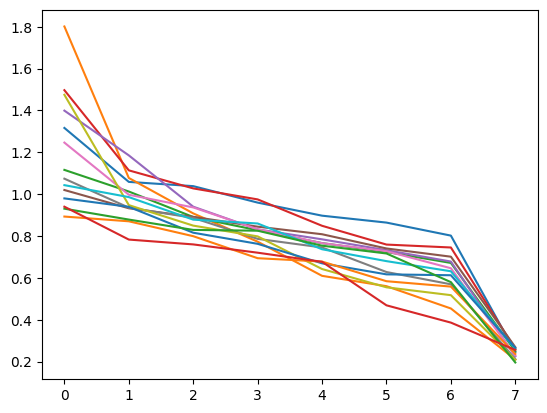

In [11]:
num_exp = 8
num_act = 2
lr = 0.02
seed = 1
#/home/ubuntu/MuP_MOE/run_data/mutransfer_lr_cccc/out_20250912_181125/width512_depth14_experts8_active2_seed0_lr0.005/router_weights_iter_1.npy
iter_idx = 10
if True:
    ind = 1000 * iter_idx + 1
    file_path =f"/home/ubuntu/MuP_MOE/run_data/mutransfer_lr_cccc/out_20250912_181125/width512_depth14_experts8_active2_seed0_lr0.005/router_weights_iter_{ind}.npy"
    router_weights = np.load(file_path) #shape (14, 8, 512)
    for i in range(14):
        plt.plot(np.linalg.svd(router_weights[i])[1])
    plt.show()

In [18]:
def parse_layer_data(text):
    lines = [line.strip() for line in text.strip().split('\n') if line.strip()]
    max_deviations = []
    usage_pattern = r'usage\[([\d\.,\-\s]+)\]'
    target_pattern = r'target=([\d\.]+)'
    for line in lines:
        if not re.match(r'^L\d+:', line):
            continue
        usage_match = re.search(usage_pattern, line)
        if not usage_match:
            continue
        usage_str = usage_match.group(1)
        usage_values = [float(x.strip()) for x in usage_str.split(',')]
        target_match = re.search(target_pattern, line)
        if not target_match:
            continue
        target = float(target_match.group(1))
        deviations = [abs(usage - target) for usage in usage_values]
        max_deviation = max(deviations)
        max_deviations.append(max_deviation)
    return np.array(max_deviations)

text = open('input.txt', 'r').read()
parse_layer_data(text)


array([0.276, 0.269, 0.286, 0.307, 0.311, 0.373, 0.293, 0.339, 0.282,
       0.305, 0.389, 0.508, 0.524, 0.551])

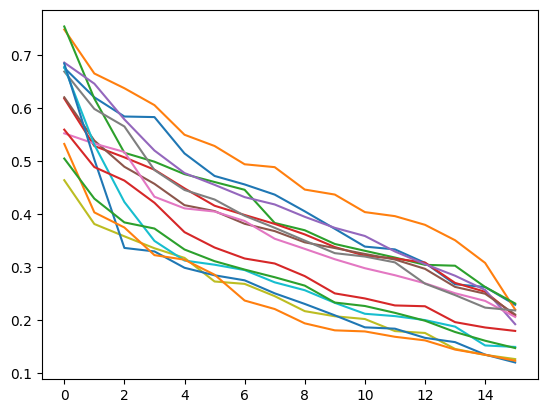

In [10]:
num_exp = 8
num_act = 2
lr = 0.02
seed = 1
#/home/ubuntu/MuP_MOE/run_data/mutransfer_lr_cccc/out_20250912_181125/width512_depth14_experts8_active2_seed0_lr0.005/router_weights_iter_1.npy
iter_idx = 10
if True:
    ind = 1000 * iter_idx + 1
    file_path =f"/home/ubuntu/MuP_MOE/run_data/mutransfer_lr_cccc/out_20250912_181125/width256_depth14_experts16_active4_seed0_lr0.005/router_weights_iter_{ind}.npy"
    router_weights = np.load(file_path) #shape (14, 8, 512)
    for i in range(14):
        plt.plot(np.linalg.svd(router_weights[i])[1])
    plt.show()
    


In [56]:
def load_router_weights(file_path='/home/ubuntu/MuP_MOE/gpt_oss_router/router_weights.pt'):
    router_weights = torch.load(file_path, map_location='cpu')
    num_layers = len(router_weights)
    matrices = []
    for i in range(num_layers):
        layer_key = f'layer_{i}'
        matrix = router_weights[layer_key].numpy()
        matrices.append(matrix)
    return matrices


In [64]:
matrices_120 = load_router_weights(file_path='/home/ubuntu/MuP_MOE/gpt_oss_router_120/router_weights.pt')
matrices_20 = load_router_weights(file_path='/home/ubuntu/MuP_MOE/gpt_oss_router/router_weights.pt')

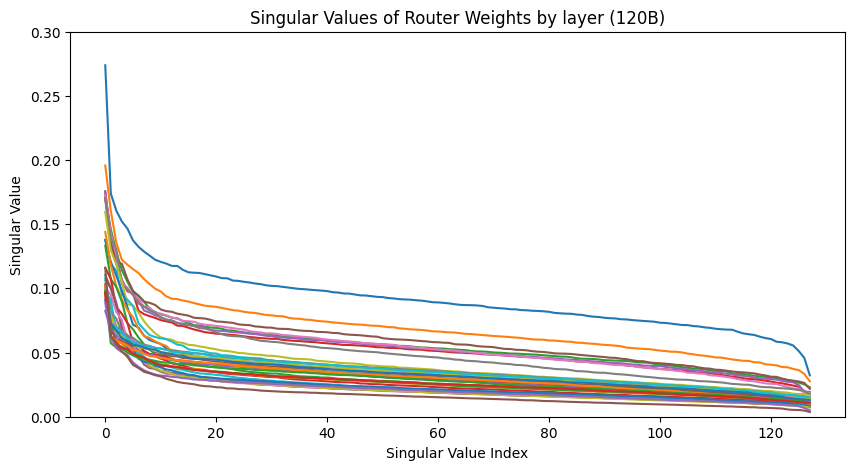

In [65]:
plt.figure(figsize=(10, 5))
for i in range(len(matrices_120)):
    matrix = np.array(matrices_120[i], dtype=np.float32)
    plt.plot(np.linalg.svd(matrix)[1]/np.sqrt(128), label=f"Layer {i}")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.ylim(0, 0.3)
plt.title("Singular Values of Router Weights by layer (120B)")
plt.show()

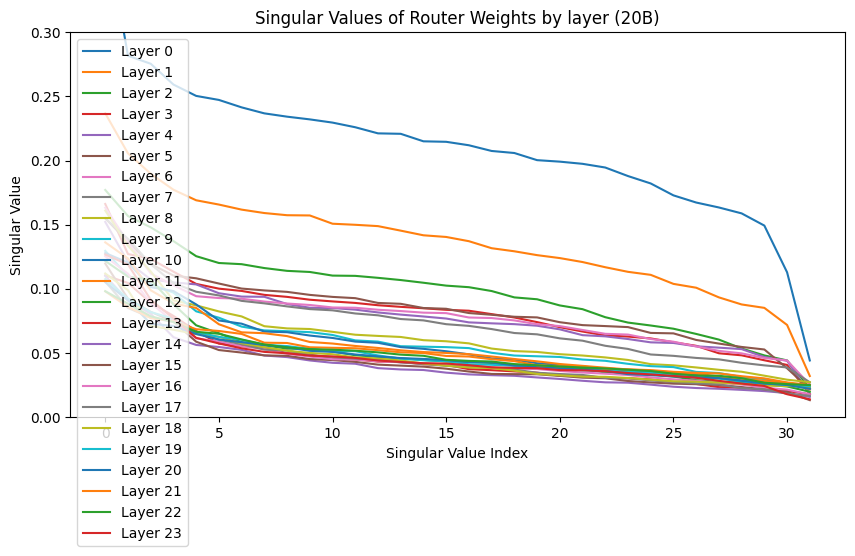

In [67]:
plt.figure(figsize=(10, 5))
for i in range(len(matrices_20)):
    matrix = np.array(matrices_20[i], dtype=np.float32)
    plt.plot(np.linalg.svd(matrix)[1]/np.sqrt(32), label=f"Layer {i}")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.ylim(0, 0.3)
plt.title("Singular Values of Router Weights by layer (20B)")
plt.legend()
plt.show()

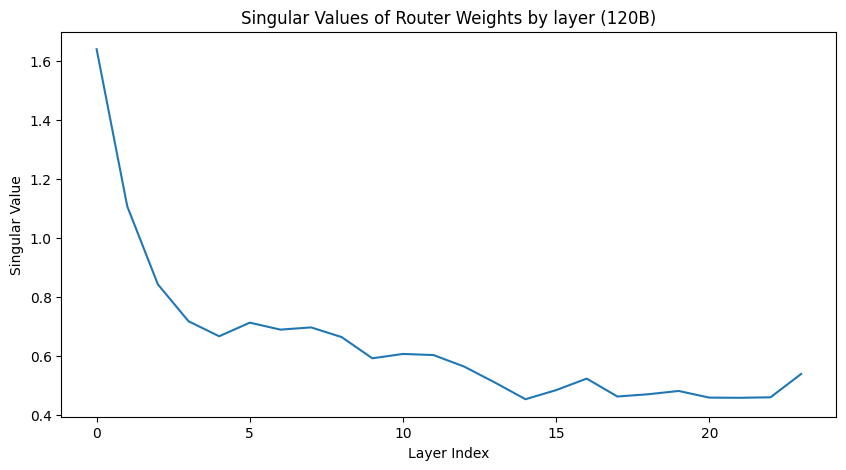

In [68]:
plt.figure(figsize=(10, 5))
list_svd = []
for i in range(len(matrices_20)):
    matrix = np.array(matrices_20[i], dtype=np.float32)
    list_svd.append(np.mean(np.linalg.svd(matrix)[1][:5]))
plt.plot(list_svd, label=f"Layer {i}")
plt.xlabel("Layer Index")
plt.ylabel("Singular Value")
plt.title("Singular Values of Router Weights by layer (120B)")
plt.show()

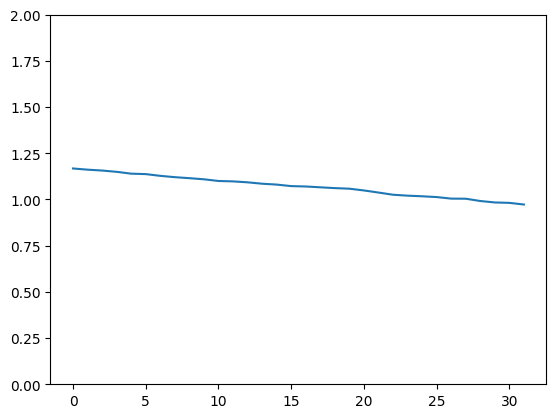

In [35]:
shape = (32, 2880)
#generate a random matrix with the same shape
matrix = np.random.randn(*shape) * 0.02
plt.plot(np.linalg.svd(matrix)[1], label=f"Random Matrix")
plt.ylim(0, 2)
plt.show()
